In [55]:
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 24.5 MB/s  0:00:00


In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud

In [4]:
csv_path = "s3://news-data-bucket-42/training/newsCorpora.csv"
df = pd.read_csv(csv_path,sep="\t", names=["TITLE","URL","PUBLISHER","CATEGORY","STORY","HOSTNAME","TIMESTAMP"])

In [5]:
df.head()

,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
1,"Fed official says weak data caused by weather,...",http://www.latimes.com/business/money/la-fi-mo...,Los Angeles Times,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.latimes.com,1394470370698
2,Fed's Charles Plosser sees high bar for change...,http://www.livemint.com/Politics/H2EvwJSK2VE6O...,Livemint,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.livemint.com,1394470371207
3,US open: Stocks fall after Fed official hints ...,http://www.ifamagazine.com/news/us-open-stocks...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371550
4,"Fed risks falling 'behind the curve', Charles ...",http://www.ifamagazine.com/news/fed-risks-fall...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371793
5,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,http://www.moneynews.com/Economy/federal-reser...,Moneynews,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.moneynews.com,1394470372027


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 422419 entries, 1 to 422937
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   TITLE      422419 non-null  object
 1   URL        422419 non-null  object
 2   PUBLISHER  422417 non-null  object
 3   CATEGORY   422419 non-null  object
 4   STORY      422419 non-null  object
 5   HOSTNAME   422419 non-null  object
 6   TIMESTAMP  422419 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 25.8+ MB


In [7]:
df.describe()

,TIMESTAMP
count,4.224190e+05
mean,1.400445e+12
std,3.733088e+09
min,1.394470e+12
25%,1.397349e+12
50%,1.399990e+12
75%,1.403775e+12
max,1.409229e+12


In [8]:
df.isna().sum()

TITLE        0
URL          0
PUBLISHER    2
CATEGORY     0
STORY        0
HOSTNAME     0
TIMESTAMP    0
dtype: int64

In [10]:
df.duplicated(subset=["TITLE","CATEGORY"]).sum()

15112

In [13]:
df[["TITLE","CATEGORY"]]

,TITLE,CATEGORY
1,"Fed official says weak data caused by weather,...",b
2,Fed's Charles Plosser sees high bar for change...,b
3,US open: Stocks fall after Fed official hints ...,b
4,"Fed risks falling 'behind the curve', Charles ...",b
5,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,b
...,...,...
422933,Surgeons to remove 4-year-old's rib to rebuild...,m
422934,Boy to have surgery on esophagus after battery...,m
422935,Child who swallowed battery to have reconstruc...,m
422936,Phoenix boy undergoes surgery to repair throat...,m


In [21]:
df_work = df[["TITLE","CATEGORY"]]

In [22]:
df_work = df_work.drop_duplicates()

In [23]:
df_work["CATEGORY"].unique()

array(['b', 't', 'e', 'm'], dtype=object)

In [24]:
df_work["CATEGORY"] = df_work["CATEGORY"].map(
    {
        "b":"Business",
        "t":"Technology",
        "e":"Entertainment",
        "m":"Health"
    }
)

In [47]:
categroy_counts = df_work["CATEGORY"].value_counts().reset_index()
categroy_counts

,CATEGORY,count
0,Entertainment,146952
1,Business,111903
2,Technology,104733
3,Health,43719


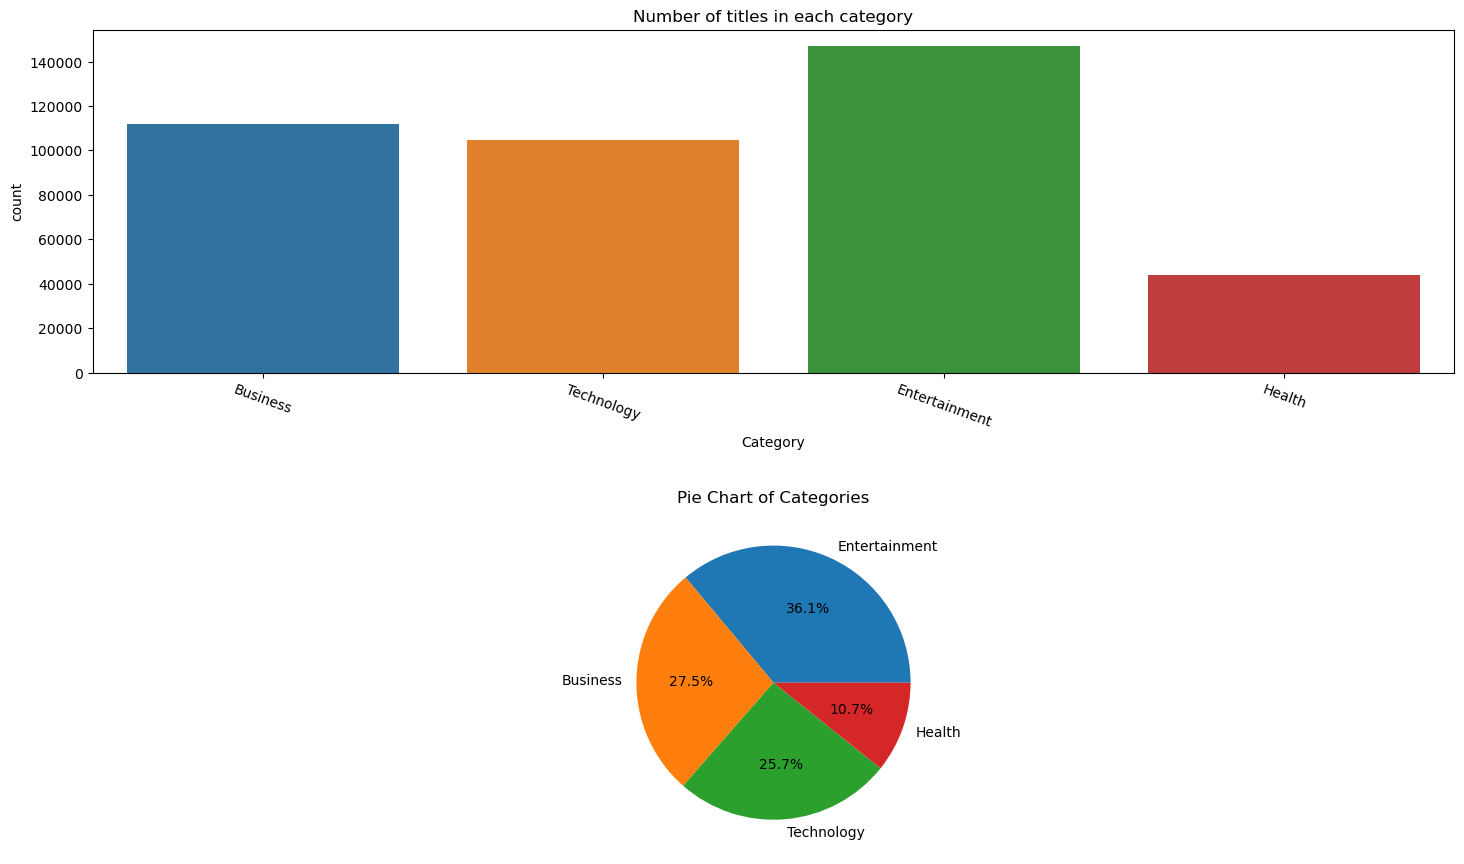

In [53]:
fig,axes = plt.subplots(2,1,figsize=(15,9))

sns.countplot(data=df_work, x="CATEGORY", ax=axes[0], hue="CATEGORY")
axes[0].set_title("Number of titles in each category")
axes[0].set_xlabel("Category")
axes[0].tick_params(axis='x', rotation=-20)


axes[1].pie(x=categroy_counts["count"],labels=categroy_counts["CATEGORY"], autopct="%1.1f%%")
axes[1].set_title("Pie Chart of Categories")

plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=3.0)
plt.show()

In [62]:
def create_category_wordcloud(df,category):
    all_text = " ".join(df[df["CATEGORY"]==category]["TITLE"].astype(str))
    wc = WordCloud(height=800, width=800, background_color="white").generate(all_text)
    return wc

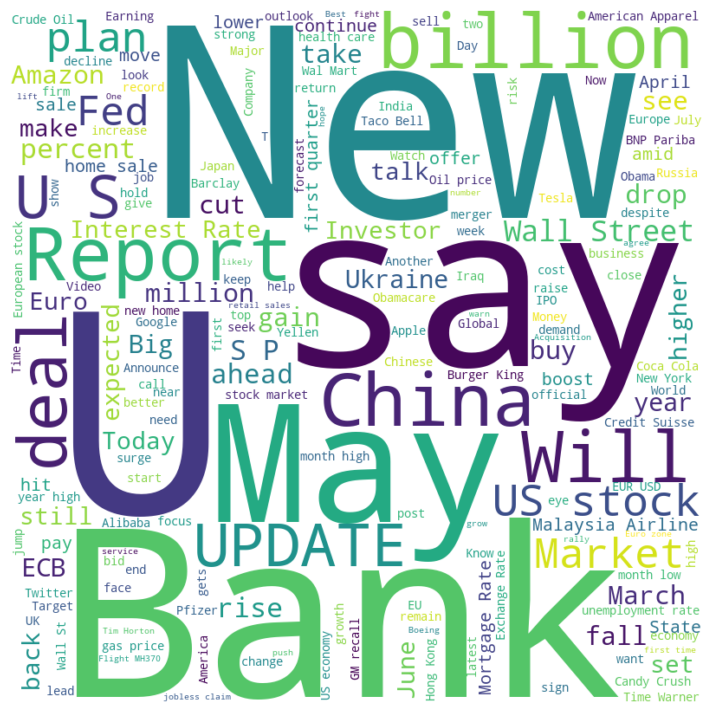

In [64]:
business_wc = create_category_wordcloud(df_work,"Business")
plt.figure(figsize=(12,9))
plt.imshow(business_wc, interpolation="bilinear")
plt.axis("off")
plt.show()

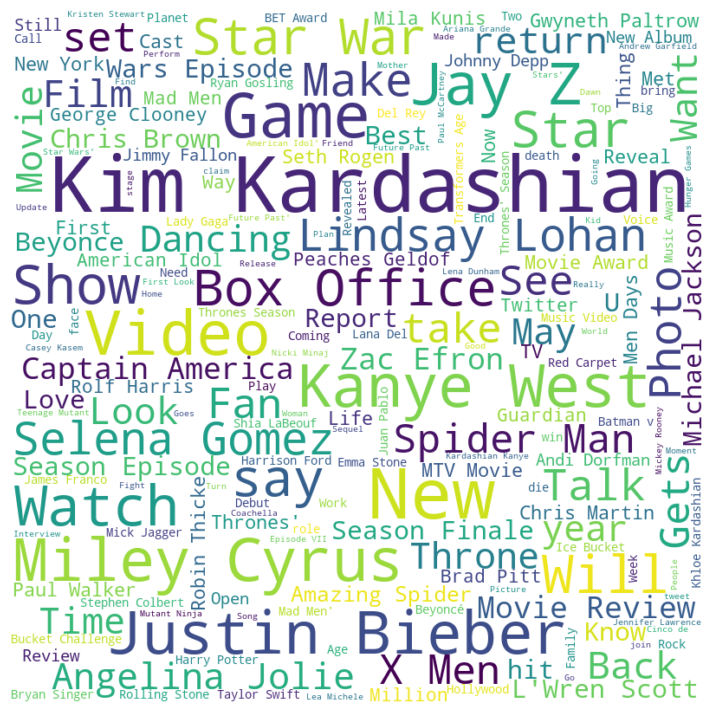

In [65]:
entertainment_wc = create_category_wordcloud(df_work,"Entertainment")
plt.figure(figsize=(12,9))
plt.imshow(entertainment_wc, interpolation="bilinear")
plt.axis("off")
plt.show()

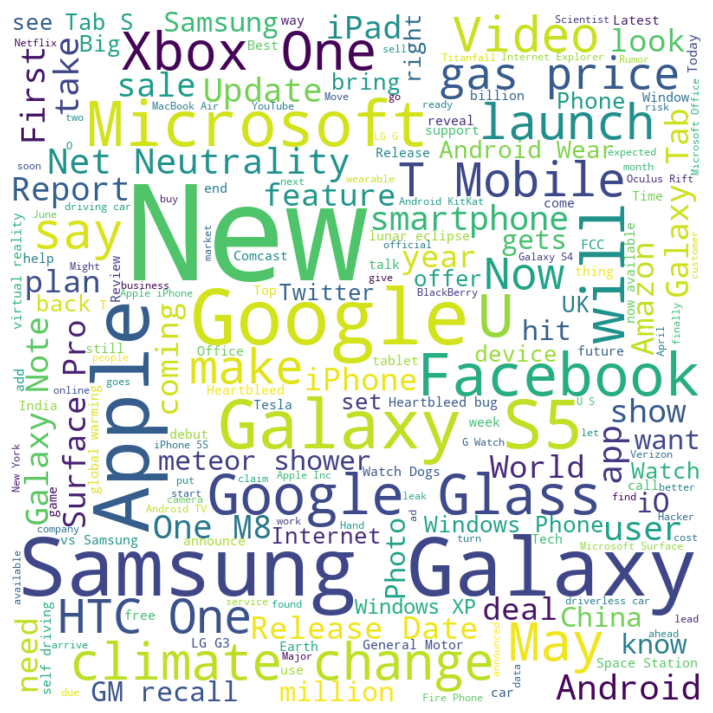

In [66]:
technology_wc = create_category_wordcloud(df_work,"Technology")
plt.figure(figsize=(12,9))
plt.imshow(technology_wc, interpolation="bilinear")
plt.axis("off")
plt.show()

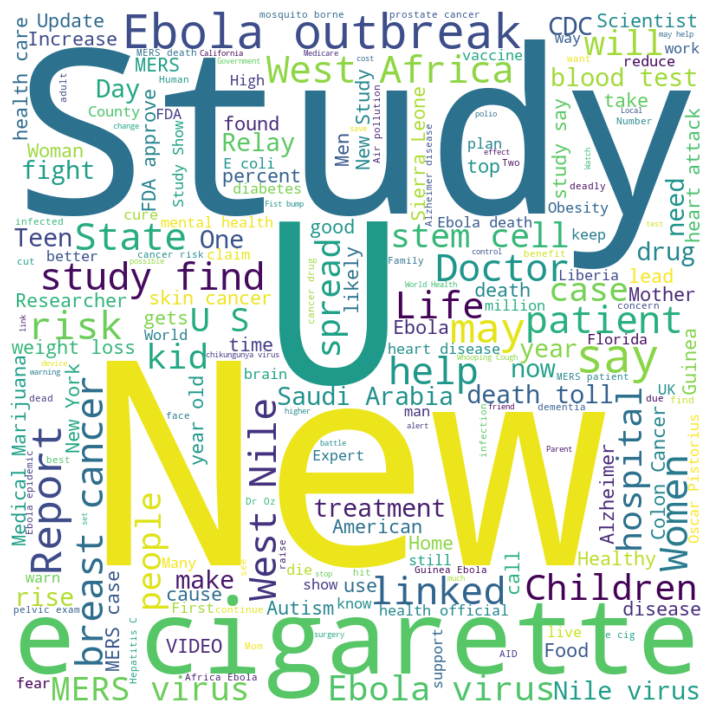

In [67]:
health_wc = create_category_wordcloud(df_work,"Health")
plt.figure(figsize=(12,9))
plt.imshow(health_wc, interpolation="bilinear")
plt.axis("off")
plt.show()